# 크로스보더 진출 우선순위 분석**배경**: K-컬처의 글로벌 확산에 따라 B2C 이커머스 플랫폼 산업에서 크로스보더 트렌드가 확대되고 있음. 국가별로 어떤 마케팅 전략이 유효한지를 실거래 데이터로 분석.**분석 방법**: 확보 가능한 실거래 데이터가 2009~2011년 것으로 한정되어, 해당 시점 데이터로 국가별 소비자 행동 패턴을 도출하고 그 시기 이커머스 기업의 마케팅 대응을 리서치로 보강해 국가별 전략 시사점을 정리한다.| Phase | 핵심 질문 | 산출물 ||---|---|---|| 1. 문제정의 | 왜 이 분석이 필요한가 | 문제정의 || 2. 전처리 | 데이터를 분석 가능한 상태로 정제 | 정제된 df_sales, 핵심 플래그 || 3. 지표 설계 | 국가를 무엇으로 비교할 것인가 | 국가별 지표 테이블 || 4. 소비자 행동 분석 | 총량 지표 이면의 개별 행동은 어떠했는가 | 국가별 미시 패턴, 이커머스 대응 전략 || 5. 결론 | 국가별 우선순위와 전략 방향 | 우선순위 매트릭스, 전략 시사점 |

## Phase 1. 문제정의- K-컬처 확산으로 해외 진출 기회가 확대되고 있으나, 실제 성공률은 국가마다 편차가 크다(일본 68% vs 미국 41%, KOTRA 2025)- 시장 선택 판단의 근거를 데이터로 구축할 필요성에서 분석을 시작- **문제정의**: 실거래 데이터로 국가별 구매 패턴을 분석해, 크로스보더 우선순위 판단 방법론을 설계한다

## Phase 2. 데이터 전처리

### 2-1. 원본 로드
- 원본(`df`)은 이후 절대 변형하지 않고 보존 (→ 취소율 계산 등에 재사용)
- 정제는 `df_sales`에서만 진행


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("online_retail_II.csv")
df_sales = df.copy()

print(df.shape)
df.head()


(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 2-2. 국가명 표준화
- EIRE/RSA/USA/Korea 같은 약어·구표기를 표준 국가명으로 통일
- Unspecified·European Community·West Indies는 특정 국가로 연결되지 않아 제외


In [2]:
country_mapping = {'EIRE': 'Ireland', 'RSA': 'South Africa', 'USA': 'United States', 'Korea': 'South Korea'}
df_sales['Country'] = df_sales['Country'].replace(country_mapping)

exclude_countries = ['Unspecified', 'European Community', 'West Indies']
df_sales = df_sales[~df_sales['Country'].isin(exclude_countries)].copy()

print(df_sales['Country'].nunique(), "개국")


40 개국


### 2-3. 타입 변환
- Customer ID → object (식별자이므로 숫자 연산 방지)
- InvoiceDate → datetime (기간 연산을 위해)


In [3]:
df_sales['Customer ID'] = df_sales['Customer ID'].astype(object)
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])


### 2-4. 결측치 처리
- Description 결측(0.41%)은 단순 제거
- Customer ID 결측은 국가별 편차가 커서(버뮤다·홍콩 100%) 삭제 대신 신뢰도 플래그로 별도 관리(2-6)


In [4]:
df_sales = df_sales.dropna(subset=['Description'])

missing_by_country = df_sales.groupby('Country')['Customer ID'].apply(lambda x: x.isna().mean() * 100)
missing_by_country.sort_values(ascending=False).head(5)


Country
Bermuda           100.000000
Hong Kong         100.000000
Bahrain            53.174603
South Africa       27.218935
United Kingdom     24.120731
Name: Customer ID, dtype: float64

### 2-5. 중복·이상치 처리
- 완전 중복 행만 제거 (Invoice+StockCode 조합 중복은 부분배송 등 정상 거래로 판단해 유지)
- 취소거래·재고조정·비상품코드(POST/DOT/M 등)·대손상각(Adjust bad debt)은 실제 판매가 아니므로 제외
- Price=0 & Quantity>0(무료 증정품)은 삭제하지 않고 플래그만 부여


In [5]:
before = len(df_sales)
df_sales = df_sales.drop_duplicates()
print(f"완전 중복 제거: {before - len(df_sales):,}건")

is_cancelled = df_sales['Invoice'].astype(str).str.startswith('C')
is_stock_adjustment = (df_sales['Quantity'] < 0) & (~is_cancelled) & (df_sales['Price'] == 0)
non_product_codes = ['POST', 'DOT', 'M', 'C2', 'BANK CHARGES', 'PADS', 'CRUK', 'AMAZONFEE']
is_non_product = df_sales['StockCode'].astype(str).isin(non_product_codes)
is_bad_debt = df_sales['Description'] == 'Adjust bad debt'

before = len(df_sales)
df_sales = df_sales[~is_cancelled & ~is_stock_adjustment & ~is_non_product & ~is_bad_debt].copy()
df_sales = df_sales.drop_duplicates()
df_sales['is_free_gift'] = (df_sales['Price'] == 0) & (df_sales['Quantity'] > 0)

print(f"이상치 제외: {before - len(df_sales):,}건")
print(f"최종: {len(df):,}건 → {len(df_sales):,}건 ({(len(df)-len(df_sales))/len(df)*100:.1f}% 제외)")


완전 중복 제거: 34,224건


이상치 제외: 24,308건
최종: 1,067,371건 → 1,003,586건 (6.0% 제외)


### 2-6. 핵심 플래그 설계 — 도매상 / 표본 신뢰도
- **도매상 플래그**: 고객별 총구매수량 상위 1% → 소수 대량구매자가 국가별 ARPU를 왜곡하는 것을 분리하기 위함
- **신뢰도 플래그**: 국가별 CustomerID 결측률<50% & 거래량≥30건 → 표본이 작은 국가가 극단값으로 왜곡되는 것을 방지
- 이 두 플래그는 Phase 3 전체에서 반복적으로 사용됨


In [6]:
df_sales['TotalPrice'] = df_sales['Quantity'] * df_sales['Price']
df_sales['Half'] = (df_sales['InvoiceDate'].dt.year.astype(str) + '-H' +
                     ((df_sales['InvoiceDate'].dt.month > 6).astype(int) + 1).astype(str))

customer_qty = df_sales.groupby('Customer ID')['Quantity'].sum()
wholesale_threshold = customer_qty.quantile(0.99)
df_sales['is_likely_wholesale'] = df_sales['Customer ID'].map(customer_qty) > wholesale_threshold

country_missing = df_sales.groupby('Country')['Customer ID'].apply(lambda x: x.isna().mean() * 100)
country_total = df_sales.groupby('Country').size()
reliability = pd.DataFrame({'missing_pct': country_missing, 'total_transactions': country_total})
reliability['reliable_for_customer_metrics'] = (
    (reliability['missing_pct'] < 50) & (reliability['total_transactions'] >= 30))

print(f"도매상 추정 거래: {df_sales['is_likely_wholesale'].sum():,}건")
print(f"신뢰 가능 국가: {reliability['reliable_for_customer_metrics'].sum()} / {len(reliability)}개국")


도매상 추정 거래: 80,526건
신뢰 가능 국가: 35 / 40개국


## 데이터 처리 기준 및 판단 근거파이프라인 전 구간에서 이뤄진 주요 판단을 고려 사항별로 분류해 정리한다.### 소비자 유형 구분분석 목적("B2C 소비자에게 브랜드가 어디서 통하는가")과 무관한 거래를 분리하기 위한 처리.| 판단 지점 | 처리 기준 | 근거 ||---|---|---|| 소매/도매 구분 | 고객별 총구매수량 상위 1%를 도매상으로 추정 | 재판매업자 거래가 섞이면 B2C 지표가 소수 대량구매자에 의해 왜곡됨 |### 결측치 및 표본 신뢰도값이 없는 것과 신뢰할 수 없는 것을 구분해, 결측이 곧 결론 왜곡으로 이어지지 않도록 하는 처리.| 판단 지점 | 처리 기준 | 근거 ||---|---|---|| CustomerID 결측(22.77%) 처리 | 삭제 대신 목적별 데이터 분리 + 국가별 신뢰도 플래그 설계 | 국가별 결측 비율 편차가 커 무작위 결측이 아님을 확인, 일괄 삭제 시 시장성이 아닌 결측 패턴에 의해 결과가 왜곡됨 || 표본 신뢰도 임계값 | 결측률 50% 미만 & 거래 30건 이상 | 30건 이상은 중심극한정리(CLT)에 따라 표본평균이 정규분포에 근사하는 최소 기준 |### 이상치 처리극단값의 발생 원인이 서로 다를 수 있다는 전제 하에, 원인별로 다르게 다룬 처리.| 판단 지점 | 처리 기준 | 근거 ||---|---|---|| 이상치 처리 방식 | IQR 대신 규칙 기반 분리(취소/재고조정/비상품코드/대손상각) | 극단값의 원인이 서로 다른 이질적 거래 유형이 섞인 것이었으며, IQR 일괄 적용 시 유효 거래 삭제 또는 제외 대상 누락 문제 발생 |### 지표 계산 원칙개별 지표를 계산할 때, 그 지표의 성격에 맞는 기준 데이터와 임계값을 선택하기 위한 처리.| 판단 지점 | 처리 기준 | 근거 ||---|---|---|| 반기 성장률 신뢰도 | 첫 반기 주문 10건 미만 시 결측 처리 | 표본이 작을 경우 소폭 변화도 극단적 비율로 나타나는 착시 확인 || ARPU 신뢰도 필터 | 매력도 점수에도 신뢰도 필터 동일 적용 | 필터 미적용 시 고객 0~1명 국가가 최고 매력도로 오분류되는 오류 확인 후 수정 || 세그먼트 신뢰 기준 | 고유 고객 5명 이상만 최종 분류 반영 | 극소 표본 국가의 상위권 오분류 방지 || 점수화 방식 | qcut 5분위 순위 기반 | 국가 간 지표 규모 편차 및 왜곡된 분포에서도 상대 비교 가능 |

## Phase 3. 지표 설계

### 3-1. 국가별 집계 테이블
- 이후 모든 지표가 여기서 파생됨


In [7]:
country_base = df_sales.groupby('Country').agg(
    total_revenue=('TotalPrice', 'sum'), order_count=('Invoice', 'nunique'),
    unique_customers=('Customer ID', 'nunique')).reset_index()

country_half_base = df_sales.groupby(['Country', 'Half']).agg(
    revenue=('TotalPrice', 'sum'), orders=('Invoice', 'nunique')).reset_index()

country_base.sort_values('total_revenue', ascending=False).head(5)


,Country,total_revenue,order_count,unique_customers
38,United Kingdom,16810893.77,36453,5339
17,Ireland,625037.53,594,5
24,Netherlands,549773.41,217,22
13,Germany,383419.24,756,107
12,France,311147.02,599,94


### 3-2. 시장 매력도 — ARPU·AOV·반기 성장률
- 총매출만 보면 "거래가 많은 시장"과 "고객당 가치가 높은 시장"이 구분되지 않음
- 전체 ARPU vs 소매(도매상 제외) ARPU를 나란히 비교해 왜곡 여부 확인
- 성장률은 첫 반기 주문 10건 미만이면 표본 착시 위험이 있어 결측 처리


In [8]:
country_base['ARPU_all'] = country_base['total_revenue'] / country_base['unique_customers']
country_base['AOV_all'] = country_base['total_revenue'] / country_base['order_count']

df_retail_only = df_sales[df_sales['is_likely_wholesale'] == False]
country_retail = df_retail_only.groupby('Country').agg(
    retail_revenue=('TotalPrice', 'sum'), retail_orders=('Invoice', 'nunique'),
    retail_customers=('Customer ID', 'nunique')).reset_index()
country_retail['ARPU_retail'] = country_retail['retail_revenue'] / country_retail['retail_customers']
country_retail['AOV_retail'] = country_retail['retail_revenue'] / country_retail['retail_orders']

country_base = country_base.merge(country_retail[['Country','ARPU_retail','AOV_retail']], on='Country', how='left')
country_base['ARPU_wholesale_gap_pct'] = (
    (country_base['ARPU_all'] - country_base['ARPU_retail']) / country_base['ARPU_all'] * 100)

half_order = sorted(df_sales['Half'].unique())
first_half, last_half = half_order[0], half_order[-1]
pivot_half = country_half_base.pivot(index='Country', columns='Half', values='revenue').fillna(0)
growth = ((pivot_half[last_half] - pivot_half[first_half]) / pivot_half[first_half].replace(0, np.nan)) * 100
country_base = country_base.merge(growth.rename('growth_rate_pct'), on='Country', how='left')

first_half_check = country_half_base[country_half_base['Half']==first_half][['Country','orders']]
first_half_check.columns = ['Country','first_half_orders']
country_base = country_base.merge(first_half_check, on='Country', how='left')
country_base['growth_reliable'] = country_base['first_half_orders'].fillna(0) >= 10
country_base.loc[~country_base['growth_reliable'], 'growth_rate_pct'] = np.nan


**그래프 1** — 국가별 ARPU: 전체 vs 소매(도매상 제외). 막대 차이가 클수록 도매상에 의한 왜곡이 큼

/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 50780 (\N{HANGUL SYLLABLE WAE}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2563995589.py:9: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show(

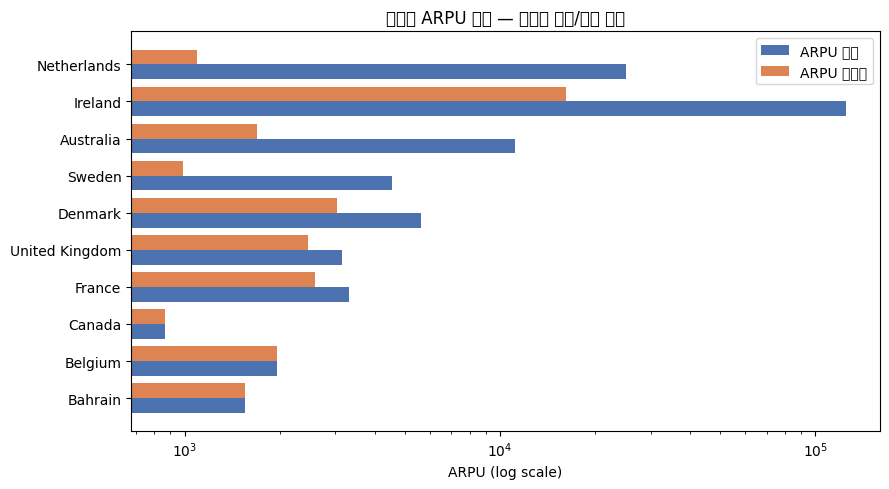

In [9]:
top = country_base.sort_values('ARPU_wholesale_gap_pct', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(top))
ax.barh([i+0.2 for i in y], top['ARPU_all'], height=0.4, label='ARPU 전체', color='#4C72B0')
ax.barh([i-0.2 for i in y], top['ARPU_retail'], height=0.4, label='ARPU 소매만', color='#DD8452')
ax.set_yticks(list(y)); ax.set_yticklabels(top['Country']); ax.invert_yaxis()
ax.set_xscale('log'); ax.set_xlabel('ARPU (log scale)')
ax.set_title('국가별 ARPU 왜곡 — 도매상 포함/제외 비교')
ax.legend(); plt.tight_layout(); plt.show()


**그래프 2** — 첫 반기 주문건수 vs 반기 성장률. 표본이 작을수록 성장률이 극단값으로 튀는지 확인

/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/2301464561.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLL

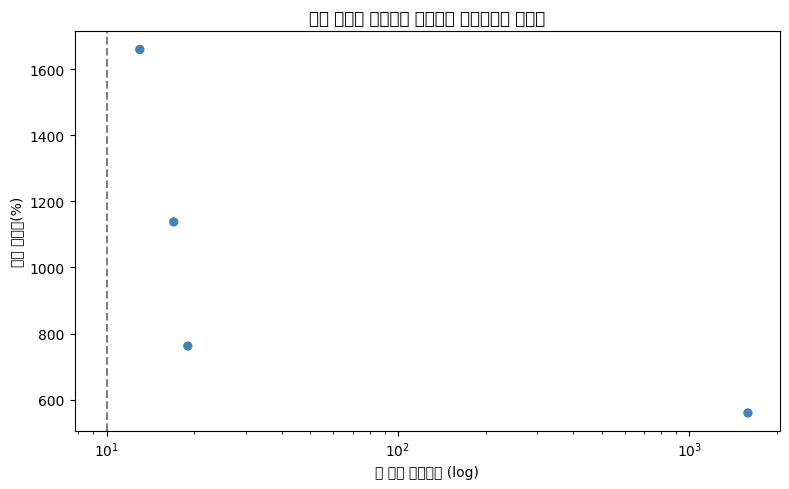

In [10]:
plot_df = country_base.dropna(subset=['growth_rate_pct'])
colors = ['red' if x < 10 else 'steelblue' for x in plot_df['first_half_orders']]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df['first_half_orders'], plot_df['growth_rate_pct'], c=colors, s=60, edgecolor='white')
ax.set_xscale('log'); ax.set_xlabel('첫 반기 주문건수 (log)'); ax.set_ylabel('반기 성장률(%)')
ax.set_title('표본 크기가 작을수록 성장률이 극단값으로 치우침')
ax.axvline(10, color='gray', linestyle='--')
plt.tight_layout(); plt.show()


### 3-3. 상품 랭킹 및 대량구매 성향
- 카테고리 컬럼이 없어(자유텍스트 상품명뿐) 테마 분류 대신 "상위 5개 상품 매출집중도"·"품목당 평균구매수량" 사용
- 품목당 구매수량이 높은 국가는 도매상 비율과 교차 확인해 원인을 분리


In [11]:
country_product_revenue = df_sales.groupby(['Country','Description'])['TotalPrice'].sum().reset_index()
top5_by_country = (country_product_revenue.sort_values(['Country','TotalPrice'], ascending=[True,False])
                    .groupby('Country').head(5))
country_total_revenue = df_sales.groupby('Country')['TotalPrice'].sum()
top5_sum = top5_by_country.groupby('Country')['TotalPrice'].sum()
concentration = (top5_sum / country_total_revenue * 100).reset_index()
concentration.columns = ['Country','top5_concentration_pct']

avg_qty_per_item = df_sales.groupby('Country')['Quantity'].mean().reset_index()
avg_qty_per_item.columns = ['Country','avg_qty_per_item']
wholesale_ratio = df_sales.groupby('Country')['is_likely_wholesale'].mean().reset_index()
wholesale_ratio.columns = ['Country','wholesale_customer_ratio']

product_summary = concentration.merge(avg_qty_per_item, on='Country').merge(wholesale_ratio, on='Country')
product_summary.sort_values('avg_qty_per_item', ascending=False).head(5)


,Country,top5_concentration_pct,avg_qty_per_item,wholesale_customer_ratio
10,Denmark,19.059459,314.029101,0.082011
4,Bermuda,51.896835,82.294118,0.000000
24,Netherlands,10.060541,77.068793,0.766947
34,Sweden,12.013790,68.900389,0.381323
20,Japan,28.613787,67.613248,0.000000


**그래프 3** — 도매상 비율 vs 품목당 구매수량. 오른쪽 위=도매상 때문 / 왼쪽 위=도매상 아닌 다른 원인

/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1010713481.py:8: UserWarning: Glyph 50984 (\N{HANGUL SYLLA

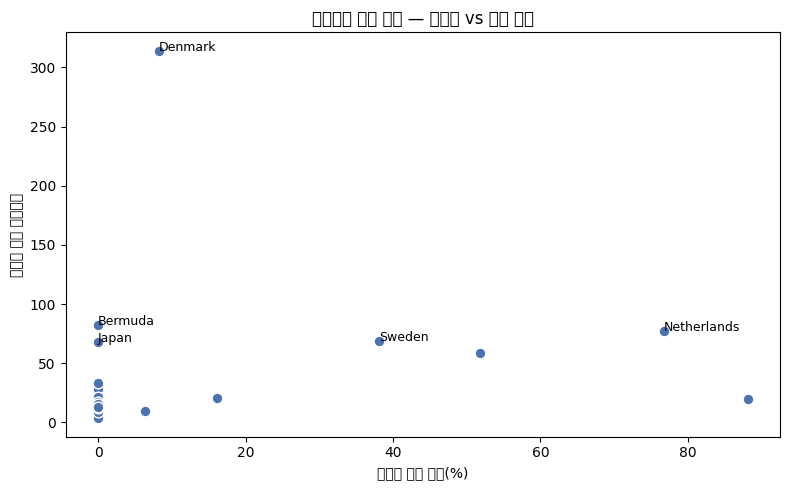

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(product_summary['wholesale_customer_ratio']*100, product_summary['avg_qty_per_item'],
           s=60, c='#4C72B0', edgecolor='white')
for _, r in product_summary.nlargest(5, 'avg_qty_per_item').iterrows():
    ax.annotate(r['Country'], (r['wholesale_customer_ratio']*100, r['avg_qty_per_item']), fontsize=9)
ax.set_xlabel('도매상 고객 비율(%)'); ax.set_ylabel('품목당 평균 구매수량')
ax.set_title('대량구매 원인 분리 — 도매상 vs 다른 요인')
plt.tight_layout(); plt.show()


### 3-4. 리스크 지표 — 취소율(원본 df 기준) / 재구매율(신뢰도 통과 국가만)
- 취소율은 취소거래가 남아있는 원본 `df`로 계산 (df_sales는 이미 취소건이 없어 분자가 0이 됨)
- 재구매율은 신뢰도 플래그를 통과한 국가만 계산


In [13]:
cancel_by_country = df.groupby('Country')['Invoice'].apply(
    lambda x: x.astype(str).str.startswith('C').sum() / len(x) * 100).reset_index()
cancel_by_country.columns = ['Country','cancel_rate_pct']

# df에도 동일 국가명 표준화 적용 (병합 정합성)
df['Country'] = df['Country'].replace(country_mapping)
cancel_by_country = df.groupby('Country')['Invoice'].apply(
    lambda x: x.astype(str).str.startswith('C').sum() / len(x) * 100).reset_index()
cancel_by_country.columns = ['Country','cancel_rate_pct']

country_total_tx = df.groupby('Country')['Invoice'].nunique().reset_index()
country_total_tx.columns = ['Country','total_invoice_count']
cancel_by_country = cancel_by_country.merge(country_total_tx, on='Country', how='left')
cancel_by_country['cancel_rate_reliable'] = cancel_by_country['total_invoice_count'] >= 30

df_cust_valid = df_sales.dropna(subset=['Customer ID'])
customer_order_count = df_cust_valid.groupby(['Country','Customer ID'])['Invoice'].nunique().reset_index()
customer_order_count.columns = ['Country','Customer ID','order_count']
repeat_rate = customer_order_count.groupby('Country').apply(
    lambda x: (x['order_count']>=2).mean()*100, include_groups=False).reset_index()
repeat_rate.columns = ['Country','repeat_purchase_rate_pct']

risk_summary = cancel_by_country.merge(repeat_rate, on='Country', how='left')
risk_summary = risk_summary.merge(reliability[['reliable_for_customer_metrics']],
                                   left_on='Country', right_index=True, how='left')
risk_summary.loc[risk_summary['reliable_for_customer_metrics']==False, 'repeat_purchase_rate_pct'] = np.nan

risk_summary[risk_summary['cancel_rate_reliable']].sort_values('cancel_rate_pct', ascending=False).head(5)


,Country,cancel_rate_pct,total_invoice_count,cancel_rate_reliable,repeat_purchase_rate_pct,reliable_for_customer_metrics
21,Japan,16.666667,56,True,70.000000,True
7,Channel Islands,5.709135,79,True,92.307692,True
14,Germany,5.225828,1095,True,77.570093,True
0,Australia,5.122844,117,True,66.666667,True
20,Italy,4.302477,92,True,64.705882,True


### 3-5. 종합 점수화 및 우선순위 매트릭스
- ARPU(소매)·성장률 → 매력도, 취소율·재구매율 → 효율성으로 qcut 5분위 점수화
- ARPU 점수에도 신뢰도 필터를 반드시 적용 (누락 시 고객 0~1명 국가가 "최고 매력도"로 잘못 나옴을 확인)


In [14]:
final = country_base.merge(product_summary[['Country','top5_concentration_pct']], on='Country', how='left')
final = final.merge(risk_summary[['Country','cancel_rate_pct','repeat_purchase_rate_pct','reliable_for_customer_metrics']],
                     on='Country', how='left')
final['growth_rate_pct'] = pd.to_numeric(final['growth_rate_pct'], errors='coerce')
final.loc[final['reliable_for_customer_metrics']==False, 'ARPU_retail'] = np.nan

def safe_qcut_score(series, ascending=True):
    valid = series.dropna()
    if len(valid) < 5: return pd.Series(np.nan, index=series.index)
    labels = list(range(1,6)) if ascending else list(range(5,0,-1))
    return pd.qcut(series.rank(method='first'), q=5, labels=labels)

final['ARPU_score'] = pd.to_numeric(safe_qcut_score(final['ARPU_retail']), errors='coerce')
final['growth_score'] = pd.to_numeric(safe_qcut_score(final['growth_rate_pct']), errors='coerce')
final['cancel_score'] = pd.to_numeric(safe_qcut_score(final['cancel_rate_pct'], ascending=False), errors='coerce')
final['repeat_score'] = pd.to_numeric(safe_qcut_score(final['repeat_purchase_rate_pct']), errors='coerce')

final['attractiveness'] = final[['ARPU_score','growth_score']].mean(axis=1)
final['efficiency'] = final[['cancel_score','repeat_score']].mean(axis=1)
final['segment_confidence'] = final['unique_customers'] >= 5

def segment_market(row):
    if pd.isna(row['attractiveness']) or pd.isna(row['efficiency']): return 'Insufficient Data'
    if row['attractiveness']>=3 and row['efficiency']>=3: return 'Priority Market'
    if row['attractiveness']<3 and row['efficiency']>=3: return 'Niche Market'
    if row['attractiveness']>=3 and row['efficiency']<3: return 'Needs Infrastructure'
    return 'Low Priority'

final['segment'] = final.apply(segment_market, axis=1)
final[final['segment_confidence']].sort_values('attractiveness', ascending=False)[
    ['Country','attractiveness','efficiency','segment','unique_customers']]


,Country,attractiveness,efficiency,segment,unique_customers
20,Japan,5.0,2.0,Needs Infrastructure,10
17,Ireland,5.0,2.0,Needs Infrastructure,5
14,Greece,5.0,3.0,Priority Market,5
35,Switzerland,5.0,4.0,Priority Market,22
7,Channel Islands,4.0,3.0,Priority Market,13
10,Denmark,4.0,3.0,Priority Market,12
13,Germany,4.0,3.0,Priority Market,107
26,Norway,4.0,3.0,Priority Market,12
12,France,4.0,2.5,Needs Infrastructure,94
38,United Kingdom,3.0,4.0,Priority Market,5339


**그래프 4** — 최종 우선순위 매트릭스 (버블 크기 = 고객 수, 신뢰 가능 국가만 표시)

/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_528/1995562121.py:13: UserWarning: Glyph 50689 (\N{HANG

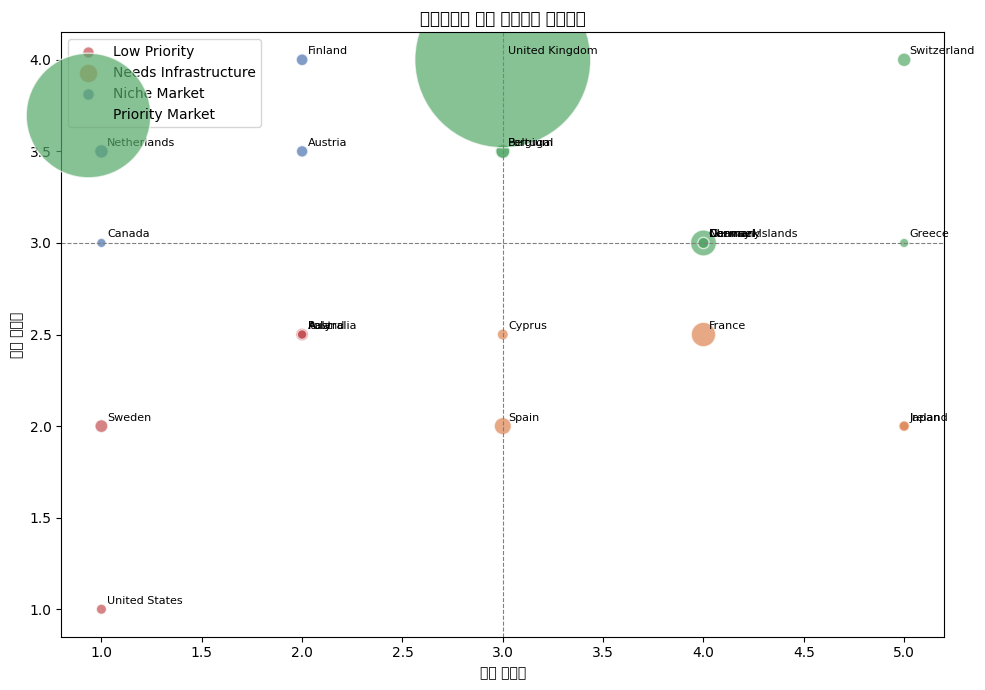

In [15]:
plot_df = final[final['segment_confidence']].dropna(subset=['attractiveness','efficiency'])
colors = {'Priority Market':'#55A868','Niche Market':'#4C72B0','Needs Infrastructure':'#DD8452','Low Priority':'#C44E52'}
fig, ax = plt.subplots(figsize=(10, 7))
for seg, group in plot_df.groupby('segment'):
    ax.scatter(group['attractiveness'], group['efficiency'], s=group['unique_customers']*3+30,
               color=colors.get(seg,'gray'), alpha=0.7, edgecolor='white', label=seg)
    for _, r in group.iterrows():
        ax.annotate(r['Country'], (r['attractiveness'], r['efficiency']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.axvline(3, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(3, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('시장 매력도'); ax.set_ylabel('운영 효율성'); ax.legend()
ax.set_title('크로스보더 진출 우선순위 매트릭스')
plt.tight_layout(); plt.show()


## Phase 4. 국가별 소비자 행동 패턴과 이커머스 기업 대응Phase 3의 매트릭스는 국가 단위 총량 지표다. 총량 지표 이면의 개별 소비자 행동(장바구니 구성, 주문 단위 금액, 취소 패턴)을 확인하고, 해당 시기 이커머스 기업의 마케팅 대응을 리서치로 보강했다.**국가 선정 기준**: Phase 3 매트릭스에서 다른 국가와 다른 패턴을 보인 곳을 우선 선정했다.- 일본: 표본이 크지 않은데도(56건) 취소율이 유럽 평균의 2~6배로 뚜렷하게 높게 나타남- 아일랜드·포르투갈·독일·프랑스: 유럽 재정위기(2010~2012) 시기와 데이터 기간이 겹치며, 매트릭스 상 매력도·효율성 점수가 서로 다른 방향으로 갈린 주요 표본국 — 아일랜드(위기 직격), 포르투갈(같은 위기국이나 다른 양상), 독일(위기 중 안정), 프랑스(대국이지만 효율성 저하)

### 5.1 일본아래 그래프는 일본의 취소 주문을 요일별로 집계한 것이다. 취소가 요일마다 고르게 퍼져있지 않고, 월~수요일에 몰려있다가 목·금요일엔 줄고 주말엔 완전히 사라지는 패턴이 나타난다.

In [16]:
# 일본: 요일별 취소 주문 건수 (행동 패턴, 금액이 아닌 빈도)japan_all = df[df['Country'] == 'Japan'].copy()japan_all['is_cancelled'] = japan_all['Invoice'].astype(str).str.startswith('C')japan_cancel_invoices = japan_all[japan_all['is_cancelled']].drop_duplicates(subset='Invoice')weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']weekday_kr = {'Monday':'월','Tuesday':'화','Wednesday':'수','Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}counts = japan_cancel_invoices['InvoiceDate'].dt.day_name().value_counts().reindex(weekday_order).fillna(0)print(counts)fig, ax = plt.subplots(figsize=(7,5))colors = ['#C44E52' if d=='Tuesday' else '#4C72B0' for d in weekday_order]bars = ax.bar([weekday_kr[d] for d in weekday_order], counts.values, color=colors)for bar, v in zip(bars, counts.values):    if v > 0:        ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{int(v)}', ha='center', fontsize=10)ax.set_ylabel('취소 주문 건수')ax.set_title('일본 — 요일별 취소 주문 건수 분포')plt.tight_layout()plt.show()

### 5.2 아일랜드아래 그래프는 아일랜드의 월별 주문 건수(구매 빈도) 추이를 구제금융 발표 시점(점선) 기준으로 색을 나눠 보여준다. 발표 이후에도 빈도가 뚝 끊기지 않고 등락을 반복하며 유지되는 패턴이 나타난다.

### 5.3 포르투갈아래 그래프는 포르투갈의 월별 구매 빈도 추이다. 구제금융 발표 이후에도 빈도가 줄어들지 않고, 오히려 후반부(2011-09~11)에 늘어나는 구간이 나타난다.

In [17]:
# 아일랜드·포르투갈: 월별 구매 빈도(주문 건수) 추이 — 금액이 아닌 빈도로 확인def order_freq_trend(country):    sub = df_sales[df_sales['Country']==country].copy()    return sub.groupby('YearMonth')['Invoice'].nunique().sort_index()for country, cdate in [('Ireland','2010-11'), ('Portugal','2011-04')]:    trend = order_freq_trend(country)    fig, ax = plt.subplots(figsize=(8,5))    colors_line = ['#C44E52' if ym >= cdate else '#4C72B0' for ym in trend.index]    ax.bar(trend.index, trend.values, color=colors_line)    idx = list(trend.index).index(cdate)    ax.axvline(idx-0.5, color='black', linestyle='--', linewidth=1, label=f'구제금융 발표({cdate})')    ax.set_ylabel('월별 주문 건수 (빈도)')    ax.set_title(f'{country} — 월별 구매 빈도 추이')    ax.tick_params(axis='x', rotation=60)    ax.legend(fontsize=9)    plt.tight_layout()    plt.show()

### 5.4 독일 · 프랑스아래 그래프는 독일·프랑스의 월별 장바구니 다양성(주문당 상품 종류 수) 추이에 선형 추세선을 함께 표시한 것이다. 옅은 선(월별 실측치)은 등락이 크지만, 진한 추세선을 보면 두 나라 모두 완만한 하락세를 보인다는 공통 패턴이 확인된다.

In [18]:
# 독일·프랑스: 월별 장바구니 다양성 추이 + 선형 추세선target_countries = ['Germany','France']basket = df_sales[df_sales['Country'].isin(target_countries)].groupby(    ['Country','YearMonth','Invoice'])['StockCode'].nunique().reset_index()basket.columns = ['Country','YearMonth','Invoice','basket_diversity']basket_monthly = basket.groupby(['Country','YearMonth'])['basket_diversity'].mean().reset_index()fig, ax = plt.subplots(figsize=(9,5))colors = {'Germany': '#4C72B0', 'France': '#C44E52'}for country in target_countries:    sub = basket_monthly[basket_monthly['Country']==country].sort_values('YearMonth').reset_index(drop=True)    x = np.arange(len(sub))    y = sub['basket_diversity'].values    ax.plot(sub['YearMonth'], y, marker='o', alpha=0.35, color=colors[country], linewidth=1)    coef = np.polyfit(x, y, 1)    trend = np.polyval(coef, x)    ax.plot(sub['YearMonth'], trend, color=colors[country], linewidth=2.5,            label=f"{country} 추세({coef[0]:+.2f}/월)")ax.set_ylabel('평균 장바구니 다양성 (주문당 상품 종류 수)')ax.set_title('독일 vs 프랑스 — 월별 장바구니 다양성 추이 (진한 선 = 추세선)')ax.legend()ax.tick_params(axis='x', rotation=45)plt.tight_layout()plt.show()

### 위 표의 미시 행동 지표 재현 코드

In [19]:
# A. 일본: 취소 vs 완료 주문의 금액대 비교japan_all = df_sales[df_sales['Country'] == 'Japan'].copy()japan_all['is_cancelled'] = japan_all['Invoice'].astype(str).str.startswith('C')japan_all['LineTotal'] = japan_all['Quantity'].abs() * japan_all['Price']japan_invoice = japan_all.groupby(['Invoice', 'is_cancelled'])['LineTotal'].sum().reset_index()print(japan_invoice.groupby('is_cancelled')['LineTotal'].agg(['mean','median','count']))print(japan_all[japan_all['is_cancelled']]['InvoiceDate'].dt.day_name().value_counts())# B. 국가별 월별 장바구니 다양성(주문당 상품 종류 수)target_countries = ['Ireland','Portugal','Germany','Japan','France']df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M').astype(str)basket = df_sales[df_sales['Country'].isin(target_countries)].groupby(    ['Country','YearMonth','Invoice'])['StockCode'].nunique().reset_index()basket.columns = ['Country','YearMonth','Invoice','basket_diversity']basket_monthly = basket.groupby(['Country','YearMonth'])['basket_diversity'].mean().unstack(0)basket_monthly.round(1)

In [20]:
# C. 아일랜드·포르투갈: 위기 전후 AOV(주문 단위, 표본 확보)crisis_dates = {'Ireland': '2010-11-01', 'Portugal': '2011-04-01'}for country, cdate in crisis_dates.items():    sub = df_sales[df_sales['Country']==country].copy()    sub['period'] = np.where(sub['InvoiceDate'] < cdate, 'pre_crisis', 'post_crisis')    aov = sub.groupby(['period','Invoice'])['TotalPrice'].sum().reset_index()    print(f"--- {country} ---")    print(aov.groupby('period')['TotalPrice'].agg(['mean','median','count']))

## 부록. 최종 데이터 산출물

Phase 2~3에서 만든 세 가지 데이터 산출물(국가별 우선순위 매트릭스, 상품 요약, 리스크 요약)을 여기 한곳에 모은다. 원래 별도 CSV 파일로 나눠 배포하던 것을 이 노트북 하나로 통합했다 — 코드·과정·결과를 분리하지 않고 이 파일 하나만 열면 전부 확인할 수 있다.

### 산출물 1. 국가별 최종 우선순위 매트릭스 (`country_priority_matrix`)

In [21]:
country_priority_matrix = final[[
    'Country', 'unique_customers', 'order_count', 'total_revenue',
    'ARPU_all', 'ARPU_retail', 'AOV_all', 'AOV_retail', 'ARPU_wholesale_gap_pct',
    'growth_rate_pct', 'growth_reliable', 'top5_concentration_pct',
    'cancel_rate_pct', 'repeat_purchase_rate_pct',
    'attractiveness', 'efficiency', 'segment', 'segment_confidence',
    'reliable_for_customer_metrics',
]].sort_values('attractiveness', ascending=False).reset_index(drop=True)

country_priority_matrix


,Country,unique_customers,order_count,total_revenue,ARPU_all,ARPU_retail,AOV_all,AOV_retail,ARPU_wholesale_gap_pct,growth_rate_pct,growth_reliable,top5_concentration_pct,cancel_rate_pct,repeat_purchase_rate_pct,attractiveness,efficiency,segment,segment_confidence,reliable_for_customer_metrics
0,Iceland,1,8,4921.53,4.921530e+03,4921.530000,615.191250,615.191250,0.000000,NaN,False,23.515858,0.000000,100.000000,5.0,5.0,Priority Market,False,True
1,Ireland,5,594,625037.53,1.250075e+05,16209.070000,1052.251734,715.106029,87.033523,762.238810,True,5.883941,2.865779,60.000000,5.0,2.0,Needs Infrastructure,True,True
2,Japan,10,33,43023.91,4.302391e+03,4302.391000,1303.754848,1303.754848,0.000000,NaN,False,28.613787,16.666667,70.000000,5.0,2.0,Needs Infrastructure,True,True
3,Greece,5,18,18711.19,3.742238e+03,3742.238000,1039.510556,1039.510556,0.000000,NaN,False,7.630193,0.904977,60.000000,5.0,3.0,Priority Market,True,True
4,Singapore,1,8,13158.16,1.315816e+04,13158.160000,1644.770000,1644.770000,0.000000,NaN,False,16.284952,2.023121,100.000000,5.0,4.0,Priority Market,False,True
5,Switzerland,22,85,94024.59,4.273845e+03,4273.845000,1106.171647,1106.171647,0.000000,NaN,False,6.610877,1.630605,86.363636,5.0,4.0,Priority Market,True,True
6,Lithuania,1,6,4892.68,4.892680e+03,4892.680000,815.446667,815.446667,0.000000,NaN,False,16.990688,0.000000,100.000000,5.0,5.0,Priority Market,False,True
7,Denmark,12,42,67422.69,5.618557e+03,3036.311818,1605.302143,902.687297,45.959229,NaN,False,19.059459,2.325581,66.666667,4.0,3.0,Priority Market,True,True
8,Israel,4,10,11328.81,2.832202e+03,2832.202500,1132.881000,1132.881000,0.000000,NaN,False,15.131333,0.539084,50.000000,4.0,3.5,Priority Market,False,True
9,France,94,599,311147.02,3.310075e+03,2580.504615,519.444107,441.402105,22.040894,1660.179036,True,7.068067,2.714585,69.148936,4.0,2.5,Needs Infrastructure,True,True


### 산출물 2. 국가별 상품 요약 (`product_summary`)

In [22]:
product_summary.sort_values('avg_qty_per_item', ascending=False).reset_index(drop=True)


,Country,top5_concentration_pct,avg_qty_per_item,wholesale_customer_ratio
0,Denmark,19.059459,314.029101,0.082011
1,Bermuda,51.896835,82.294118,0.000000
2,Netherlands,10.060541,77.068793,0.766947
3,Sweden,12.013790,68.900389,0.381323
4,Japan,28.613787,67.613248,0.000000
5,Australia,7.768140,58.264838,0.517357
6,Thailand,44.454721,33.578947,0.000000
7,Czech Republic,35.844116,27.916667,0.000000
8,Singapore,16.284952,21.045181,0.000000
9,France,7.068067,20.559456,0.161006


### 산출물 3. 국가별 리스크 요약 (`risk_summary`)

In [23]:
risk_summary.sort_values('cancel_rate_pct', ascending=False).reset_index(drop=True)


,Country,cancel_rate_pct,total_invoice_count,cancel_rate_reliable,repeat_purchase_rate_pct,reliable_for_customer_metrics
0,United States,23.551402,25,False,37.500000,True
1,Japan,16.666667,56,True,70.000000,True
2,Czech Republic,16.666667,5,False,NaN,False
3,South Korea,15.873016,3,False,0.000000,True
4,Saudi Arabia,10.000000,2,False,NaN,False
5,United Arab Emirates,6.600000,22,False,50.000000,True
6,Nigeria,6.250000,3,False,100.000000,True
7,Channel Islands,5.709135,79,True,92.307692,True
8,Malta,5.685619,16,False,100.000000,True
9,Germany,5.225828,1095,True,77.570093,True


### (선택) 파일로 저장하고 싶다면

아래 셀은 Colab 세션 내 `/content/`에 CSV로 저장한다. 노트북 자체가 산출물을 포함하고 있으므로 필수는 아니며, 별도 파일이 필요할 때만 실행한다.

In [24]:
country_priority_matrix.to_csv('./country_priority_matrix.csv', index=False)
product_summary.to_csv('./product_summary.csv', index=False)
risk_summary.to_csv('./risk_summary.csv', index=False)
df_sales.to_csv('./df_sales_cleaned.csv', index=False)
print("저장 완료")


저장 완료


## 6. 최종 결론이 결론은 국가 우선순위를 매기는 것이 아니라, **소비자 행동이 어떤 사회·시대적 맥락에서 어떤 패턴으로 나타났고, 그 국면에서 어떤 마케팅 전략이 효과적이었는지**를 국가별로 종합하는 데 있다. 다섯 국가는 Phase 3 매트릭스에서 다른 국가와 구분되는 패턴(취소율 이상치, 유럽 재정위기 시기 상반된 반응)을 보여 선정했다.| 국가 | 사회·시대적 맥락 | 소비자 행동 패턴 | 효과적이었던 마케팅 전략 ||---|---|---|---|| 일본 | 비현금 결제 인프라 미비, 카드결제에 대한 문화적 기피 | 주중 초반(월~수)에 몰린 소액 시험구매 후 이탈, 주말엔 취소 없음 | 편의점 대안 결제수단 도입, 랭킹·리뷰 기반 신뢰 마케팅 || 아일랜드 | 2010-11 EU·IMF 구제금융, 긴축 재정 | 구매 빈도는 유지, 건당 지출만 지속 축소(AOV -21.5%) | 가치 중심 프로모션(Nielsen 2011 업계 트렌드) || 포르투갈 | 같은 위기 3국 중 하나, 긴축에도 실물경기 지속 악화 | 구매 빈도는 유지·일부 증가, 건당 지출은 완만히 축소 | 아일랜드와 동일한 가치 중심 프로모션 트렌드 || 독일 | 유로존 위기 중 자본이 몰리는 안전자산 경제 지위 | 장바구니 다양성이 완만히 하락하나 상대적으로 낙폭이 작음 | 후불(송장) 결제를 통한 신뢰 구축 || 프랑스 | 2011년 하반기 신용등급 강등 우려 고조 | 장바구니 다양성이 독일보다 더 큰 폭으로 하락 | 한정시간 플래시세일을 통한 긴급성 마케팅(벙트프리베) |국가별 데이터 수치와 세부 근거는 5장(국가별 소비자 행동 패턴과 이커머스 기업 대응)에 정리했다.